# Duckify Simulation notebook

### Connect to the simulator / to the robot

In [ ]:
import sys
from pathlib import Path
import json
import numpy as np

# Make sure ur3e-control is on the path
sys.path.insert(0, str(Path.cwd().parents[1]))

from URBasic import Joint6D, TCP6D

In [ ]:
SIMULATION = True

In [ ]:
from duckify_simulation.duckify_sim import DuckifySim

# # Connect to the simulator
duckify_sim = DuckifySim()
print("Connected to simulator")

In [ ]:
from URBasic import ISCoin

In [ ]:
# Create a new ISCoin object
# UR3e1 IP (closest to window): 10.30.5.158
# UR3e2 IP: 10.30.5.159
if not SIMULATION:
    iscoin = ISCoin(host="10.30.5.158", opened_gripper_size_mm=40)

In [ ]:
robot_sim = duckify_sim.robot_control
if not SIMULATION:
    robot_true = iscoin.robot_control

## Default home position

This joint position is equivalent to this one:
```txt
home_tcp = TCP6D.createFromMetersRadians(
      0.0,      # x
     -0.35,     # y
      0.20,     # z
      0.0,      # rx
      3.14,      # ry
      0.0       # rz
  )
```



In [ ]:
# Go to home position
home = Joint6D.createFromRadians(1.1859, -1.4452, 1.2389, -1.3639, -1.5693, -0.3849)

In [ ]:
robot_sim.movej(home)
if SIMULATION:
    tcp_home = robot_sim.get_actual_tcp_pose()

In [ ]:
if not SIMULATION:
    robot_true.movej(home)
    tcp_home = robot_true.get_actual_tcp_pose()

In [ ]:
print(f"Home TCP: {tcp_home}")

In [ ]:
# target_tcp = TCP6D.createFromMetersRadians(
#       0.0,      # x
#      -0.35,     # y
#       0.20,     # z
#       0.0,      # rx
#       3.14,      # ry
#       0.0       # rz
#   )

In [ ]:
# current_joints = robot.get_actual_joint_positions()
# target_joints = robot.get_inverse_kin(target_tcp, qnear=current_joints)

## Set TCP

In [ ]:
if not SIMULATION:
    from src.calibration import collect_data
    NUM_MEASURES = 20

    tcps = collect_data(robot_true, NUM_MEASURES)
else:
    tcps = [
        [0.0024946337740892888, -0.3594913915339868, 0.06033167700558813, -0.62069755529755, -2.369727486212462, -0.13752393611863362],
        [-0.07482225018547103, -0.35685269130655106, 0.07009337653443365, 1.9372057315922462, 2.190232377619723, 0.6719840297817087],
        [-0.08776793211801745, -0.2979812165503483, 0.051154992555969794, 2.3781388566898687, 0.2623998383341909, 0.7178051284770465],
        [-0.0006933205535983589, -0.340924257935631, 0.06551204074775754, -2.879088789274111, -0.4716877213448937, 0.8276834472055694],
        [-0.04094004360899719, -0.3437262194580261, 0.0786140415986546, -3.087426800813378, 0.2627406174702693, 0.06421242457662117],
        [0.026621421400990636, -0.3469050147213359, 0.033956680032955974, -2.5014091646201537, -0.22918589994059693, 1.5168173293250897],
    ]

In [ ]:
if not SIMULATION:
    print(tcps)

[[0.028533490347645397, -0.31109465460613095, 0.23037800055185004, -0.03902721135395715, 3.0039359769448053, 0.25879601110414835], [0.04070036769452461, -0.37113960768411935, 0.2125973906353641, 0.21676788816964732, 3.0190849072732604, 0.6810791442926443], [-0.07247576683262541, -0.3410562973788976, 0.1836582060618127, 0.8380312702922266, 2.4781083495166643, 0.668741719781228], [0.018845402918898017, -0.2672961403208637, 0.23212330834225875, 0.6521231770007128, 2.9075562268057027, 0.06014033582977424], [0.1389037041702792, -0.2747582208239761, 0.2210446468939047, 0.23195019545982434, -2.785446594946776, -0.07564819823761751], [0.07925696701738864, -0.24776884356818038, 0.23381927770023883, -0.3089855168582696, -3.04021980814857, 0.14317086672993937], [0.05203899712099123, -0.3872849372302552, 0.20517169114947625, -0.28350873935977217, -2.9994143048558874, -0.7872375326947326]]

In [ ]:
from src.calibration import get_tcp_offset, validate_calibration
tcp_offset = get_tcp_offset(tcps)
robot_sim.set_tcp(tcp_offset)
if not SIMULATION:
    robot_true.set_tcp(tcp_offset)
motion_val_cal = validate_calibration(robot_sim)

for m in motion_val_cal:
    robot_sim.movel(m)

In [ ]:
if not SIMULATION:
    robot_true.freedrive_mode()
    input("Put the robot in position for validate calibration.")
    robot_true.end_freedrive_mode()

    motion_val_cal = validate_calibration(robot_true)

    input("Ready to move?")
    for m in motion_val_cal:
        robot_true.movel(m)

TCP6D([-0.08607243040435382, -0.31652067645872695, -0.01145586981217811, 0.3950286753506294, -3.0978815742747186, -0.018834692394685076])

Joint6D([0.9133668541908264, -1.5068980169347306, 1.8483932654010218, -1.9195991955199183, -1.5847447554217737, -0.91443378130068])

## Compute Transformation object2robot

In [ ]:
file_path = "trapezoid_letters-trapezoid_letters-trace.json"
with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)
print(data["generated_at"])

In [150]:
from src.transformation import collect_data as collect_data_tf

p_world = np.array(data["calibration"])

if len(p_world) < 4:
    print("Missing point")

if not SIMULATION:
    p_tcp = collect_data_tf(robot_true, p_world)
else:
    p_tcp = np.array([
        [-0.03389773, -0.2829937,   0.09458801],# -0.24982057, -3.09150359, -0.18723581],
        [-0.03366482, -0.31970029,  0.09458314],# -0.28493231, -3.12244751, -0.07563827],
        [ 0.02527303, -0.32058601,  0.09427673],#  0.21952408,  3.00241046,  0.09098521],
        [ 0.05483491, -0.26206449,  0.05878293]#,  0.18852376, -2.79599659, -0.21783004]
    ])
    p_tcp = np.array([
        [-30, 35.753, -19.358],
        [-30, 35.753, 19.358],
        [30, 35.753, 19.358],
        [60, 0, -40]
    ])

In [60]:
if not SIMULATION:
    print(p_world)
    print(p_tcp)

---- transformation function ----

In [134]:
def _normal_to_rxyz(n):
    x,y,z = n
    z = -z
    rx = np.arctan2(-y, np.sqrt(x**2 + z**2))
    ry = np.arctan2(x, z)
    rz = 0
    return [rx,ry,rz]

In [ ]:
import numpy as np

def normalize(v):
    v = np.asarray(v, dtype=float)
    n = np.linalg.norm(v)
    return v / n if n > 0 else v

def rotation_matrix_from_vectors(a, b):
    """
    Retourne la matrice qui aligne le vecteur a sur le vecteur b.
    Utilise la formule de Rodrigues.
    """
    a = normalize(a)
    b = normalize(b)

    v = np.cross(a, b)
    c = np.dot(a, b)
    s = np.linalg.norm(v)

    if s == 0:
        # vecteurs colinéaires
        if c > 0:
            return np.eye(3)
        else:
            # rotation de 180° autour d'un axe orthogonal
            axis = np.array([1, 0, 0])
            if abs(a[0]) > 0.9:
                axis = np.array([0, 1, 0])
            axis = normalize(np.cross(a, axis))
            K = np.array([[0, -axis[2], axis[1]],
                          [axis[2], 0, -axis[0]],
                          [-axis[1], axis[0], 0]])
            return np.eye(3) + 2 * K @ K

    K = np.array([[0, -v[2], v[1]],
                  [v[2], 0, -v[0]],
                  [-v[1], v[0], 0]])

    R = np.eye(3) + K + K @ K * ((1 - c) / (s**2))
    return R

def euler_from_matrix(R):
    """
    Convertit une matrice de rotation en Euler XYZ (intrinsèque).
    """
    sy = np.sqrt(R[0,0]**2 + R[1,0]**2)

    singular = sy < 1e-6

    if not singular:
        x = np.arctan2(R[2,1], R[2,2])
        y = np.arctan2(-R[2,0], sy)
        z = np.arctan2(R[1,0], R[0,0])
    else:
        x = np.arctan2(-R[1,2], R[1,1])
        y = np.arctan2(-R[2,0], sy)
        z = 0

    return np.array([x, y, z])  # en radians

def _normal_to_rxyz(normal):
    z_axis = np.array([0, 0, 1])
    R = rotation_matrix_from_vectors(z_axis, normal)
    return euler_from_matrix(R)

In [168]:
def create_transformation(A, B):
    A = np.asarray(A)[:, :3]
    B = np.asarray(B)[:, :3]
    assert A.shape == B.shape
    N = A.shape[0]

    # Build matrix for affine solve: [A | 1]
    P = np.hstack([A, np.ones((N, 1))])  # Nx4

    # Solve P @ X = B, where X is 4×3 (R^T and t)
    X, _, _, _ = np.linalg.lstsq(P, B, rcond=None)

    # Extract R and t
    R = X[:3, :].T   # 3×3
    t = X[3, :]      # 3

    # Build full 4×4 affine matrix
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = t

    # Normal transform
    R_normal = R # np.linalg.inv(R).T
    T_normal = np.eye(4)
    T_normal[:3, :3] = R_normal

    def AtoB(p):
        p = np.asarray(p)
        point = p[:3]
        normal = p[3:]
        # Transform point
        p_new = T @ [*point, 1]

        # Transform normal
        nx,ny,nz = normal
        n_new = T_normal @ [nx,ny,nz, 1]
        #n_new /= np.linalg.norm(n_new)
        r_new = _normal_to_rxyz(n_new[:3])

        return [*p_new[:3], *n_new[:3]]

    return AtoB


In [172]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def rvec_to_rotmat(rvec):
    r = np.array(rvec)
    theta = np.linalg.norm(r)
    if theta < 1e-9:
        return np.eye(3)

    u = r / theta
    ux, uy, uz = u

    K = np.array([
        [0, -uz, uy],
        [uz, 0, -ux],
        [-uy, ux, 0]
    ])

    R = np.eye(3)*np.cos(theta) + (1-np.cos(theta))*np.outer(u, u) + np.sin(theta)*K
    return R

def plot_2d_projections(x_axis, y_axis, z_axis, axs):
    # --- XY plane ---
    axs[0].arrow(0, 0, x_axis[0], x_axis[1], color='r')
    axs[0].arrow(0, 0, y_axis[0], y_axis[1], color='g')
    axs[0].arrow(0, 0, z_axis[0], z_axis[1], color='b')
    axs[0].set_title(f"XY plane")
    axs[0].set_aspect('equal')
    axs[0].grid(True)

    # --- XZ plane ---
    axs[1].arrow(0, 0, x_axis[0], x_axis[2], color='r')
    axs[1].arrow(0, 0, y_axis[0], y_axis[2], color='g')
    axs[1].arrow(0, 0, z_axis[0], z_axis[2], color='b')
    axs[1].set_title(f"XZ plane")
    axs[1].set_aspect('equal')
    axs[1].grid(True)

    # --- YZ plane ---
    axs[2].arrow(0, 0, y_axis[1], y_axis[2], color='g')
    axs[2].arrow(0, 0, z_axis[1], z_axis[2], color='b')
    axs[2].arrow(0, 0, x_axis[1], x_axis[2], color='r')
    axs[2].set_title(f"YZ plane")
    axs[2].set_aspect('equal')
    axs[2].grid(True)


def plot_reuler(rvec, name=""):
    R = rvec_to_rotmat(rvec)
    # 3D plot
    fig, axs = plt.subplots(1, 4, figsize=(16,4))
    ax = axs[0]
    ax = fig.add_subplot(141, projection='3d')

    # TCP axes after rotation
    x_axis = R @ np.array([1,0,0])
    y_axis = R @ np.array([0,1,0])
    z_axis = R @ np.array([0,0,1])

    # Draw axes
    ax.quiver(0,0,0, x_axis[0], x_axis[1], x_axis[2], color='r', length=0.5)
    ax.quiver(0,0,0, y_axis[0], y_axis[1], y_axis[2], color='g', length=0.5)
    ax.quiver(0,0,0, z_axis[0], z_axis[1], z_axis[2], color='b', length=0.5)

    # Formatting
    ax.set_xlim([-1,1])
    ax.set_ylim([-1,1])
    ax.set_zlim([-1,1])
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    plot_2d_projections(x_axis, y_axis, z_axis, axs[1:])

    plt.title(f"TCP Orientation, {name}")
    plt.show()


def plot_normal(normal, name=""):
    n = np.array(normal)

    fig = plt.figure(figsize=(16,4))

    # --- 3D ---
    ax3d = fig.add_subplot(1, 4, 1, projection='3d')
    ax3d.quiver(0,0,0, n[0], n[1], n[2], color='k', length=1.0)
    ax3d.set_xlim([-1,1]); ax3d.set_ylim([-1,1]); ax3d.set_zlim([-1,1])
    ax3d.set_title(f"Normale 3D – {name}")
    ax3d.set_xlabel("X"); ax3d.set_ylabel("Y"); ax3d.set_zlabel("Z")

    # --- XY ---
    ax_xy = fig.add_subplot(1, 4, 2)
    ax_xy.arrow(0,0, n[0], n[1], color='k')
    ax_xy.set_aspect('equal'); ax_xy.grid(True)
    ax_xy.set_title("XY")

    # --- XZ ---
    ax_xz = fig.add_subplot(1, 4, 3)
    ax_xz.arrow(0,0, n[0], n[2], color='k')
    ax_xz.set_aspect('equal'); ax_xz.grid(True)
    ax_xz.set_title("XZ")

    # --- YZ ---
    ax_yz = fig.add_subplot(1, 4, 4)
    ax_yz.arrow(0,0, n[1], n[2], color='k')
    ax_yz.set_aspect('equal'); ax_yz.grid(True)
    ax_yz.set_title("YZ")

    plt.tight_layout()
    plt.show()


---- Create transformation function ----

[[-30.     35.753 -19.358]
 [-30.     35.753  19.358]
 [ 30.     35.753  19.358]
 [ 60.      0.    -40.   ]]

 
[[-2.46780962e-02 -2.73070621e-01  3.72949143e-02  7.28589470e-01
   2.55660028e+00  3.67059431e-01]
 [-2.36625898e-02 -3.11057752e-01  3.73873553e-02  7.40850918e-01
   2.49226370e+00  2.76853978e-01]
 [ 3.54433603e-02 -3.08652138e-01  3.74047430e-02  3.65150801e-01
   3.09870083e+00  2.90510505e-01]
 [ 6.26750495e-02 -2.49590824e-01  1.60884378e-03  5.31000235e-01
  -2.60594978e+00 -3.50139203e-01]]

In [170]:
obj2robot = create_transformation(p_world, p_tcp)

[np.float64(-3.310284141274007e-16), np.float64(-7.771561172376096e-16), np.float64(1.0)]


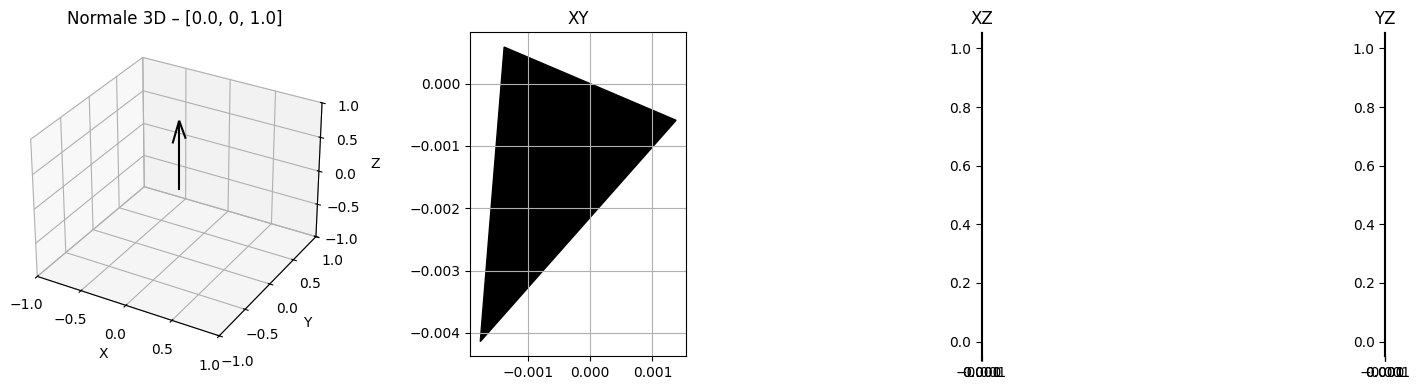

[np.float64(-7.344507851030163e-16), np.float64(1.0000000000000024), np.float64(-1.9984014443252818e-15)]


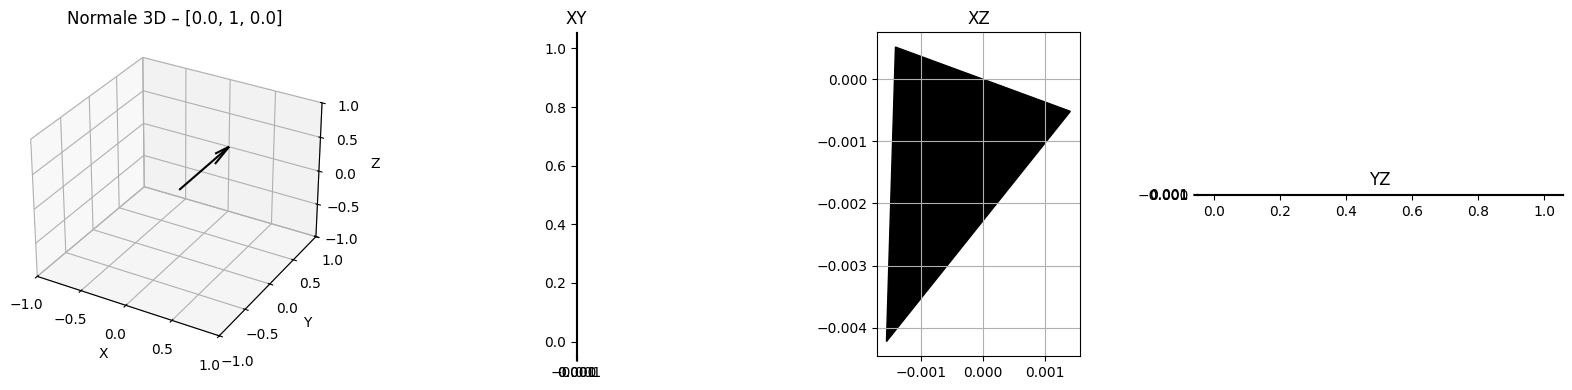

[np.float64(1.0000000000000002), np.float64(3.673584746135052e-16), np.float64(-8.583945224889713e-16)]


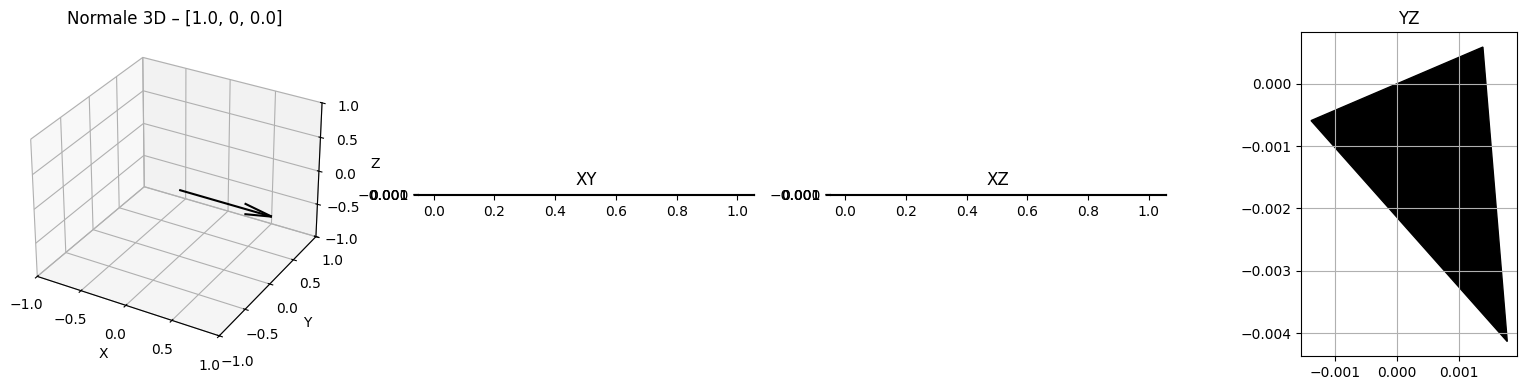

[np.float64(-7.3445078510301625e-16), np.float64(1.0000000000000022), np.float64(-1.9984014443252814e-15)]


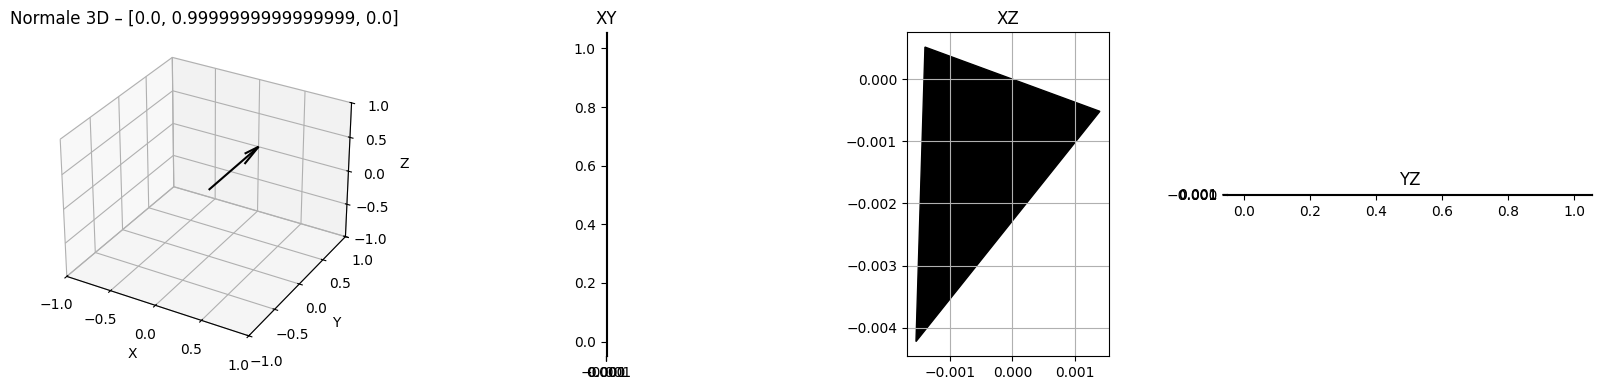

[np.float64(-6.539043773448181e-16), np.float64(0.49999994254797125), np.float64(0.8660254369543797)]


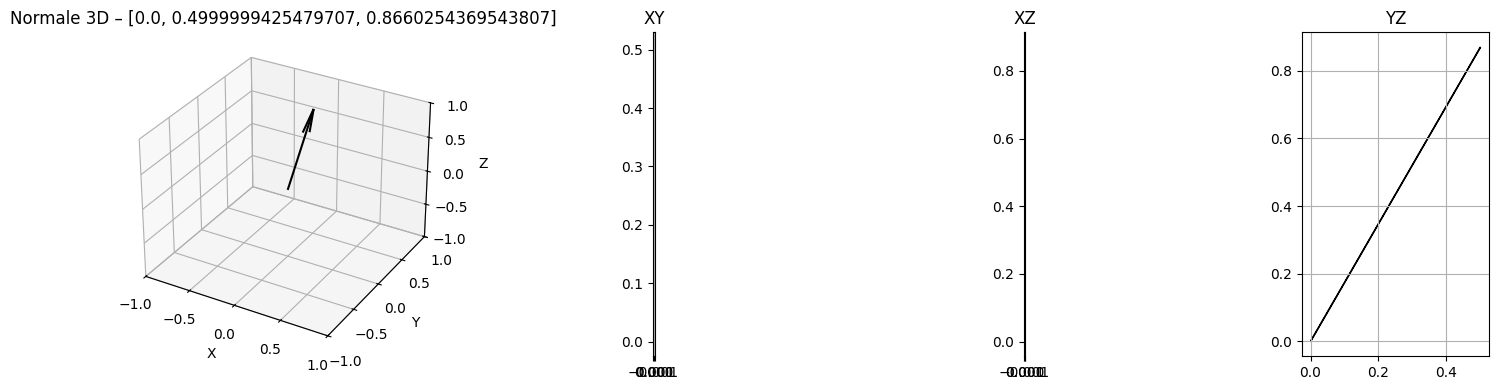

[np.float64(-8.054644887471225e-17), np.float64(0.5000000781485989), np.float64(-0.8660253586653214)]


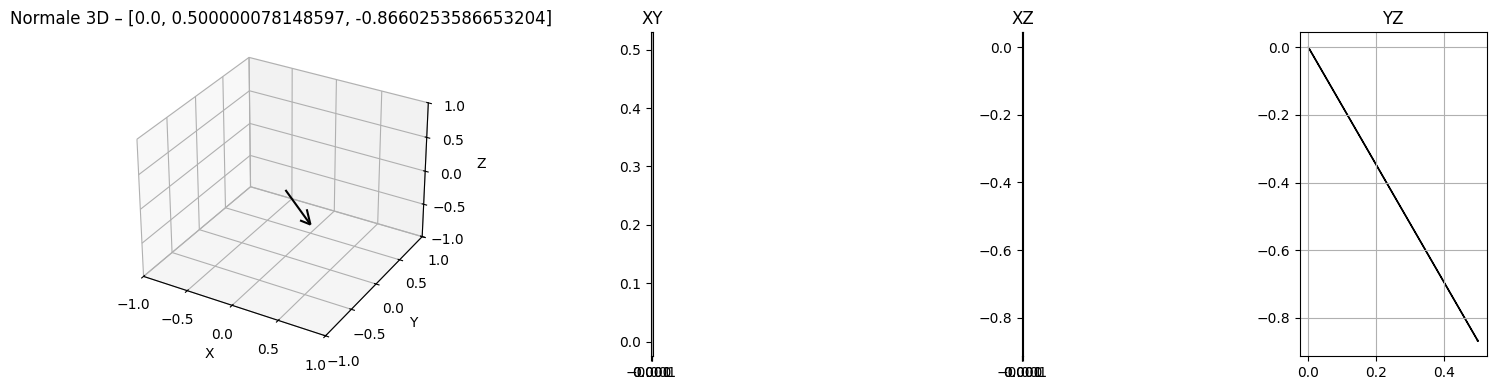

[np.float64(0.7660444804970834), np.float64(0.642787565141047), np.float64(-1.9421159846138017e-15)]


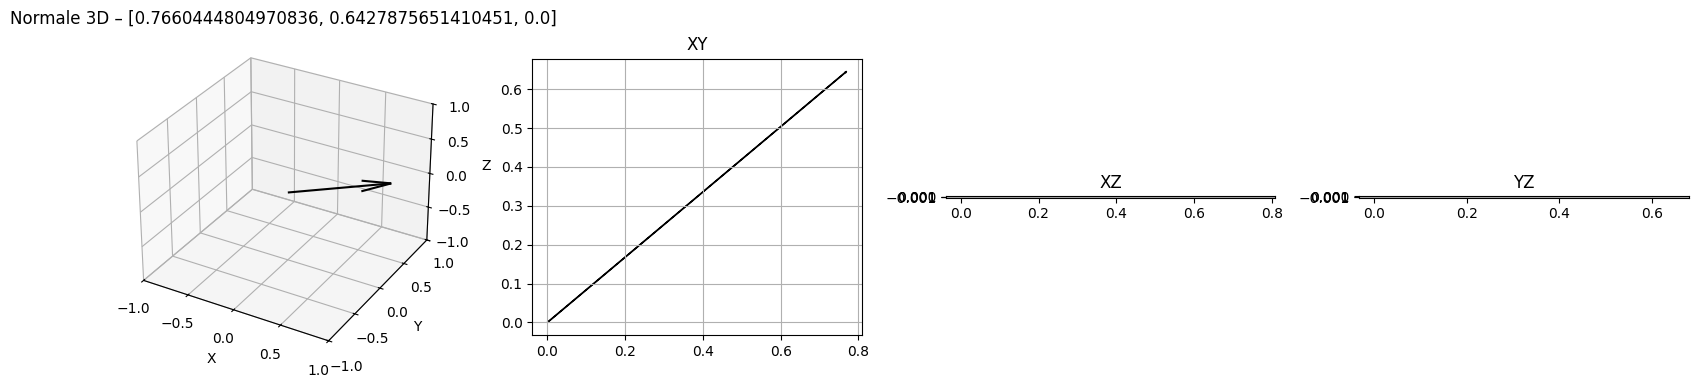

[np.float64(-0.7660444410855514), np.float64(0.6427876121098831), np.float64(4.820907028126181e-08)]


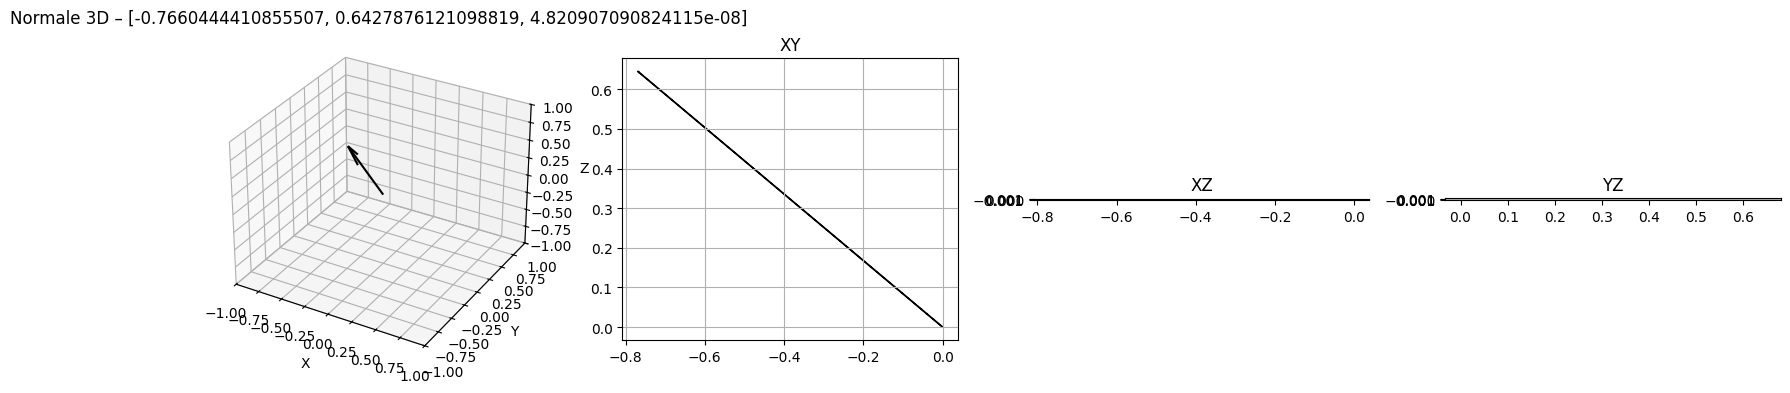

In [173]:
p_w = [0,0,0]
faces = [
    [0.0, 0, 1.0],
    [0.0, 1, 0.0],
    [1.0, 0, 0.0],
    [0.0, 0.9999999999999999, 0.0],
    [0.0, 0.4999999425479707, 0.8660254369543807],
    [0.0, 0.500000078148597, -0.8660253586653204],
    [0.7660444804970836, 0.6427875651410451, 0.0],
    [-0.7660444410855507, 0.6427876121098819, 4.820907090824115e-08]
]

for f in faces:
    t = obj2robot([*p_w, *f])
    rvec = t[3:]  # rx, ry, rz
    print(rvec)
    #plot_reuler(rvec,f"{f}")
    plot_normal(rvec,f"{f}")

## Generate trajectory

---- transformation function ----

In [31]:
def _rotvec_to_rotmat(r):
    theta = np.linalg.norm(r)
    if theta < 1e-12:
        return np.eye(3)
    k = r / theta
    K = np.array([[0, -k[2], k[1]],
                  [k[2], 0, -k[0]],
                  [-k[1], k[0], 0]])
    return np.eye(3) + np.sin(theta)*K + (1-np.cos(theta))*(K @ K)

def _rotmat_to_rotvec(R):
    theta = np.arccos((np.trace(R) - 1) / 2)
    if theta < 1e-12:
        return np.zeros(3)
    rx = (R[2,1] - R[1,2]) / (2*np.sin(theta))
    ry = (R[0,2] - R[2,0]) / (2*np.sin(theta))
    rz = (R[1,0] - R[0,1]) / (2*np.sin(theta))
    return theta * np.array([rx, ry, rz])

def tcp_trans(tcp1, tcp2):
    # Décomposition
    p1 = np.array(tcp1[:3])
    r1 = np.array(tcp1[3:])
    p2 = np.array(tcp2[:3])
    r2 = np.array(tcp2[3:])
    # Matrices de rotation
    R1 = _rotvec_to_rotmat(r1)
    R2 = _rotvec_to_rotmat(r2)

    # Composition
    p_new = p1 + R1 @ p2
    R_new = R1 @ R2
    r_new = _rotmat_to_rotvec(R_new)

    return np.concatenate([p_new, r_new])

---- Create trajectory ----

In [32]:
# from src.transformation import tcp_trans
traces = data["traces"]
draw_motions = []
move_motions = []
above = [0,0,-0.02,0,0,0]
for trace in traces:
    normal = trace["face"]
    normal[2] = - normal[2]
    t_world = trace["path"]
    motion = []
    
    # Drawing motion
    for i, p in enumerate(t_world):
        p_w = (*p, *normal)
        x,y,z,rx,ry,rz = obj2robot(p_w)
        
        # Add entry point
        if i == 0:
            x_t,y_t,z_t,_,_,_ = tcp_trans([x,y,z,rx,ry,rz], above)
            m = TCP6D.createFromMetersRadians(x_t,y_t,z_t, rx,ry,rz)
            motion.append(m)

        # Add drawing point
        m = TCP6D.createFromMetersRadians(x,y,z, rx,ry,rz)
        motion.append(m)

        # Add exit point
        if i == len(t_world)-1:
            x_t,y_t,z_t,_,_,_ = tcp_trans([x,y,z,rx,ry,rz], above)
            m = TCP6D.createFromMetersRadians(x_t,y_t,z_t, rx,ry,rz)
            motion.append(m)
    
    if motion:
        draw_motions.append(motion)
        move_motions.append((motion[0], motion[-1]))
    #break

In [33]:
move_outside = []
for m in range(len(move_motions)):
    if m == 0:
        move_outside.append([home, move_motions[m][0]])
    else:
        move_outside.append([move_motions[m-1][-1], home, move_motions[m][0]])
move_outside.append([move_motions[-1][-1], home])

## Drawing algorithm

### Drawing algorithm simulation

movej sent (duration=3s)
Movement OK — target reached
top
[0.0, 0.9999999999999999, 0.0]
movej sent (duration=3s)
Movement OK — target reached
TCP6D([0.0006160330416391613, -0.350407626063329, 0.2653366127630044, -5.066447371095e-06, 3.139981903280988, -1.4319116960396927e-05])
movej sent (duration=2s)
Movement OK — target reached
TCP6D([-0.014532589699901677, -0.3073043209420538, 0.11448482215513381, 9.969413049399048e-05, -3.1363953323508764, 0.0])


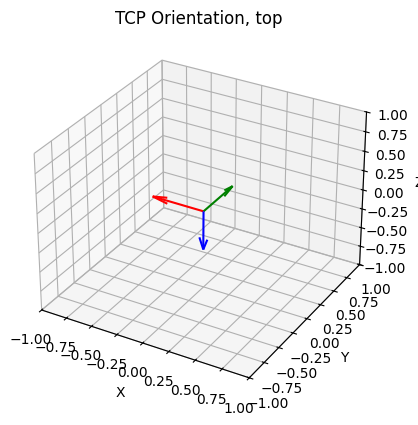


right
[0.7660444804970836, 0.6427875651410451, 0.0]
movej sent (duration=2s)
Movement OK — target reached
TCP6D([-0.014558439122412094, -0.3032304548400114, 0.11448536265012169, 9.969413049399048e-05, -3.1363953323508764, 0.0])


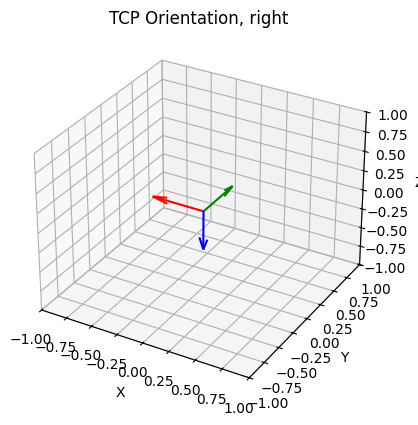

movej sent (duration=3s)
Movement DONE — but target not fully reached (possible collision?)
TCP6D([0.00061603304163846, -0.35040762606332904, 0.2653366127630059, -5.066447311078864e-06, 3.1399819032683327, -1.4319117091805545e-05])
movej sent (duration=2s)
Movement OK — target reached
TCP6D([0.049740968936598504, -0.2980846494033853, 0.09611704075631236, -0.004765418476329431, -2.271306470917294, 0.0])


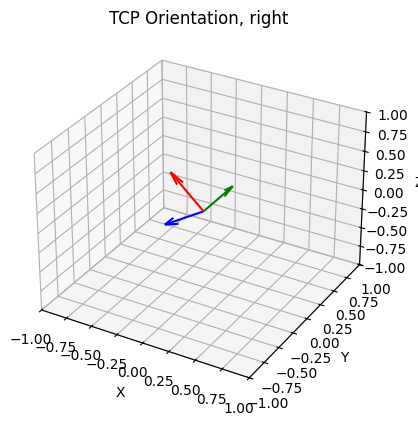


top
[0.0, 0.4999999425479707, 0.8660254369543807]
movej sent (duration=2s)
Movement OK — target reached
TCP6D([0.05807661263127567, -0.2974593853734576, 0.08622623438051161, -0.004765418476329431, -2.271306470917294, 0.0])


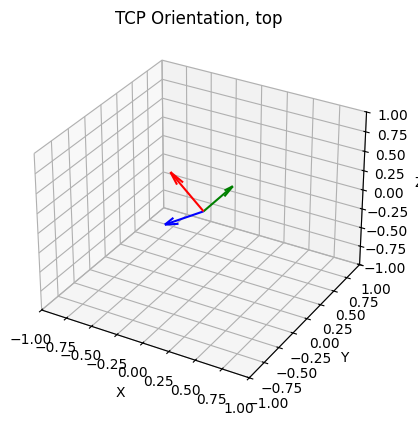

movej sent (duration=3s)
Movement OK — target reached
TCP6D([0.000616033041639638, -0.3504076260633293, 0.26533661276300474, -5.066447340728109e-06, 3.139981903405119, -1.4319116961784802e-05])
movej sent (duration=2s)
Movement OK — target reached
TCP6D([-0.010492773845122092, -0.27742935676494235, 0.10304363607867634, 1.1252594732526686, 3.11531848524934, 0.0])


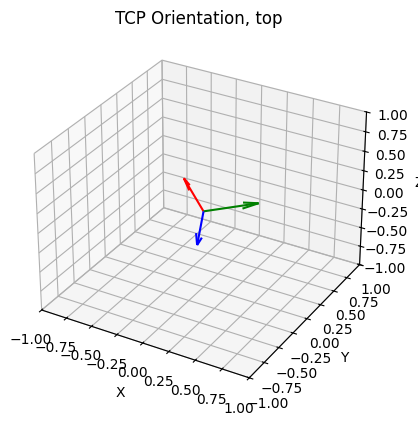


bottom
[0.0, 0.500000078148597, -0.8660253586653204]
movej sent (duration=2s)
Movement OK — target reached
TCP6D([-0.010481601591794532, -0.2766662503136355, 0.10183181984699832, 1.1252594732526686, 3.11531848524934, 0.0])


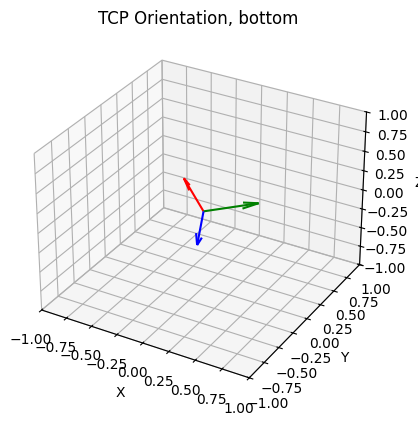

movej sent (duration=3s)
Movement OK — target reached
TCP6D([0.0006160330416384598, -0.35040762606332904, 0.2653366127630059, -5.066447309617554e-06, 3.1399819032683327, -1.4319117060606964e-05])
movej sent (duration=2s)
Movement DONE — but target not fully reached (possible collision?)
TCP6D([-0.01709754642453415, -0.3329094312453707, 0.0855677164896394, -1.0084978700335714, -3.1125437811899714, 0.0])


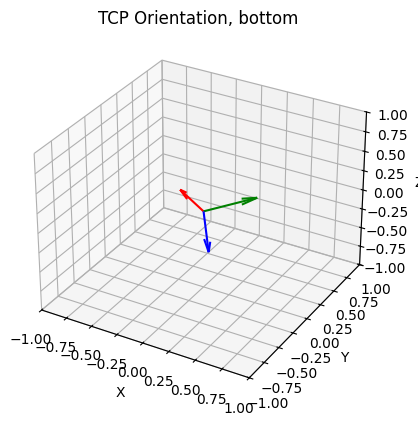


left
[-0.7660444410855507, 0.6427876121098819, 4.820907090824115e-08]
movej sent (duration=2s)
Movement OK — target reached
TCP6D([-0.017238441456047846, -0.328766786933577, 0.09424156852255315, -1.0084978700335714, -3.1125437811899714, 0.0])


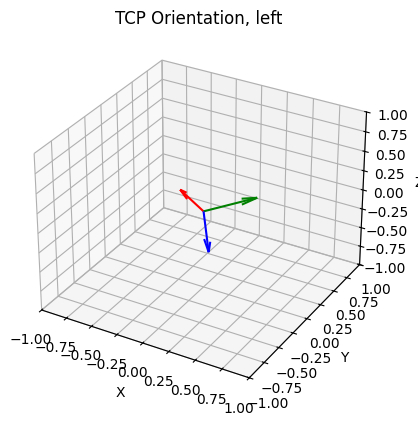

movej sent (duration=3s)
Movement OK — target reached
TCP6D([0.0006160330416389388, -0.3504076260633297, 0.26533661276300474, -5.0664473559023165e-06, 3.139981903278476, -1.4319117006500471e-05])
movej sent (duration=2s)
Movement DONE — but target not fully reached (possible collision?)
TCP6D([-0.07612997230592206, -0.2917853241752314, 0.07471428122812261, 0.004981390379891859, 2.2599746781251744, 0.0])


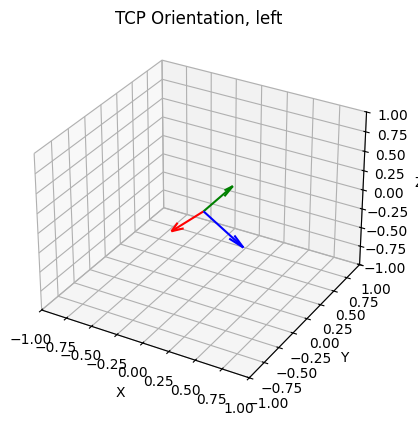


Return home
movej sent (duration=2s)
Movement OK — target reached
TCP6D([-0.0747032296353417, -0.2919392130208223, 0.07644465263227167, 0.004981390379891859, 2.2599746781251744, 0.0])
movej sent (duration=3s)
Movement OK — target reached
TCP6D([0.0006160330416389039, -0.3504076260633297, 0.26533661276300474, -5.066447357252998e-06, 3.139981903278075, -1.431911704165739e-05])


In [34]:
robot_sim.movej(home)
for k in range(len(move_motions)):
    
    # Move in position
    print(data["traces"][k]["name"])
    print(data["traces"][k]["face"])
    for m in move_outside[k]:
        if isinstance(m, TCP6D):
            robot_sim.movel(m)
            print(m)
            plot_reuler([m.rx,m.ry,m.rz], data["traces"][k]["name"] )
        
        elif isinstance(m, Joint6D):
            robot_sim.movej(m)
            print(robot_sim.get_actual_tcp_pose())
    
    print()

    # Draw on object
    #for m in draw_motions[k]:
    #    robot_sim.movel(m, a=0.5, v=0.1)

print("Return home")
for m in move_outside[-1]:
    if isinstance(m, TCP6D):
        robot_sim.movel(m)
        print(m)
    elif isinstance(m, Joint6D):
        robot_sim.movej(m)
        print(robot_sim.get_actual_tcp_pose())


### Drawing algorithm test move to position

The robot will move around the object to reach positions.

```text
                   home -> input position
output position -> home -> input position
output position -> home
```

In [ ]:
if not SIMULATION:
    robot_true.freedrive_mode()
    input("Ready to move? (Close to home position)")
    robot_true.end_freedrive_mode()

In [ ]:
if not SIMULATION:
    robot_true.movej(home)
    for k in range(len(move_motions)):
        
        # Move in position
        print(data["traces"][k]["face"])
        for m in move_outside[k]:
            if isinstance(m, TCP6D):
                robot_true.movel(m)
                print(m)
            
            elif isinstance(m, Joint6D):
                robot_true.movej(m)
                print(robot_true.get_actual_tcp_pose())
        
        print()

    print("Return home")
    for m in move_outside[-1]:
        if isinstance(m, TCP6D):
            robot_true.movel(m)
            print(m)
        elif isinstance(m, Joint6D):
            robot_true.movej(m)
            print(robot_true.get_actual_tcp_pose())

### Drawing algorithm test drawing

The robot will move around the object and draw on it.

```text
                   home -> input position -> draw
output position -> home -> input position -> draw
output position -> home
```

In [ ]:
if not SIMULATION:
    robot_true.movej(home)
    for k in range(len(move_motions)):
        
        # Move in position
        print(data["traces"][k]["face"])
        for m in move_outside[k]:
            if isinstance(m, TCP6D):
                robot_true.movel(m)
                print(m)
            
            elif isinstance(m, Joint6D):
                robot_true.movej(m)
                print(robot_true.get_actual_tcp_pose())
        
        print()

        # Draw on object
        for m in draw_motions[k]:
            robot_true.movel(m, a=0.5, v=0.1)

    print("Return home")
    for m in move_outside[-1]:
        if isinstance(m, TCP6D):
            robot_true.movel(m)
            print(m)
        elif isinstance(m, Joint6D):
            robot_true.movej(m)
            print(robot_true.get_actual_tcp_pose())